# Multilingual Image Editing Error Classifier — MagicBrush Pipeline

**Full pipeline:** Data Loading → Translation → Annotation → Training

- **Dataset:** `osunlp/MagicBrush` (2000 samples from train split)
- **Languages:** English, Hindi, Bangla, Nepali
- **Annotation:** LLaVA-v1.6 7B (4-bit) — 11-class error taxonomy
- **Training:** BLIP-2 vision + XLM-RoBERTa text → dual-image cross-attention classifier
- **Target:** Kaggle T4 GPU (16GB VRAM)

Each phase saves a checkpoint file. If the notebook restarts, it resumes from the last checkpoint.

In [1]:
# Cell 1: Install dependencies
!pip install -q datasets transformers bitsandbytes accelerate sacrebleu sentencepiece Pillow pandas torch torchvision tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.3 MB/s eta 0:00:00


In [2]:
# Cell 2: Config & Paths
import os, sys, json, re, gc, shutil
import numpy as np
import pandas as pd
import torch
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

# ── Environment ──
IS_KAGGLE = os.path.exists("/kaggle/working")
OUTPUT_DIR = "/kaggle/working" if IS_KAGGLE else "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_DIR_SRC = os.path.join(OUTPUT_DIR, "images", "source")
IMAGE_DIR_TGT = os.path.join(OUTPUT_DIR, "images", "target")
os.makedirs(IMAGE_DIR_SRC, exist_ok=True)
os.makedirs(IMAGE_DIR_TGT, exist_ok=True)

# ── Dataset ──
HF_DATASET = "osunlp/MagicBrush"
SUBSET_SIZE = 2000
SEED = 42

# ── Translation ──
TRANSLATION_MODELS = {
    "hi": "Helsinki-NLP/opus-mt-en-hi",
    "bn": "Helsinki-NLP/opus-mt-en-mul",
    "ne": "Helsinki-NLP/opus-mt-en-mul",
}
BACK_TRANSLATION_MODELS = {
    "hi": "Helsinki-NLP/opus-mt-hi-en",
    "bn": "Helsinki-NLP/opus-mt-mul-en",
    "ne": "Helsinki-NLP/opus-mt-mul-en",
}
LANGUAGE_TAGS = {"bn": ">>ben<<", "ne": ">>npi<<"}

# ── Annotation ──
ANNOTATION_MODEL = "llava-hf/llava-v1.6-mistral-7b-hf"
ERROR_TAXONOMY = {
    0: "Wrong Object", 1: "Missing Object", 2: "Extra Object",
    3: "Wrong Attribute", 4: "Spatial Error", 5: "Style Mismatch",
    6: "Over-editing", 7: "Under-editing", 8: "Artifact/Quality",
    9: "Ambiguous Prompt", 10: "Failed Removal",
}
NUM_ERROR_CLASSES = 11

# ── Checkpoint Paths ──
CKPT_DATA    = os.path.join(OUTPUT_DIR, "ckpt_01_data.parquet")
CKPT_TRANS   = os.path.join(OUTPUT_DIR, "ckpt_02_translated.parquet")
CKPT_ANNOT   = os.path.join(OUTPUT_DIR, "ckpt_03_annotated.parquet")
MODEL_SAVE   = os.path.join(OUTPUT_DIR, "trained_model")

# ── Training ──
TRAIN_EPOCHS = 5
BATCH_SIZE = 4
GRAD_ACCUM = 8
LR = 2e-5
VAL_SPLIT = 0.15

print(f"IS_KAGGLE:  {IS_KAGGLE}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

IS_KAGGLE:  True
OUTPUT_DIR: /kaggle/working
GPU: Tesla T4


---
## Phase 1: Data Loading & Image Saving
Load MagicBrush, sample 2000, save images to disk.

In [3]:
# Cell 3: Load dataset and save images
if os.path.exists(CKPT_DATA):
    print(f"Checkpoint found: {CKPT_DATA} — skipping data loading.")
    df = pd.read_parquet(CKPT_DATA)
    print(f"Loaded {len(df)} samples from checkpoint.")
else:
    from datasets import load_dataset
    
    print(f"Loading {HF_DATASET}...")
    dataset = load_dataset(HF_DATASET, split="train")
    print(f"Full dataset: {len(dataset)} samples")
    print(f"Columns: {dataset.column_names}")
    
    # Sample SUBSET_SIZE rows
    np.random.seed(SEED)
    indices = np.random.choice(len(dataset), size=min(SUBSET_SIZE, len(dataset)), replace=False)
    indices.sort()
    print(f"Sampled {len(indices)} indices.")
    
    # Save images and build metadata
    records = []
    for new_idx, ds_idx in enumerate(tqdm(indices, desc="Saving images")):
        sample = dataset[int(ds_idx)]
        sample_id = f"{new_idx:06d}"
        
        src_path = os.path.join(IMAGE_DIR_SRC, f"{sample_id}.jpg")
        tgt_path = os.path.join(IMAGE_DIR_TGT, f"{sample_id}.jpg")
        
        src_img = sample["source_img"]
        if isinstance(src_img, Image.Image):
            src_img.convert("RGB").save(src_path, quality=95)
        
        tgt_img = sample["target_img"]
        if isinstance(tgt_img, Image.Image):
            tgt_img.convert("RGB").save(tgt_path, quality=95)
        
        records.append({
            "sample_id": sample_id,
            "dataset_index": int(ds_idx),
            "img_id": sample["img_id"],
            "turn_index": sample.get("turn_index", 0),
            "source_image_path": f"images/source/{sample_id}.jpg",
            "target_image_path": f"images/target/{sample_id}.jpg",
            "instruction": sample["instruction"],
        })
    
    df = pd.DataFrame(records)
    df.to_parquet(CKPT_DATA, index=False)
    
    # Free HF dataset memory
    del dataset
    gc.collect()
    
    print(f"\nSaved {len(df)} samples to {CKPT_DATA}")

print(f"Source images: {len(os.listdir(IMAGE_DIR_SRC))}")
print(f"Target images: {len(os.listdir(IMAGE_DIR_TGT))}")
print(df[["sample_id", "img_id", "instruction"]].head())

Loading osunlp/MagicBrush...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

data/train-00000-of-00051-9fd9f23e2b1cb3(…):   0%|          | 0.00/506M [00:00<?, ?B/s]

data/train-00001-of-00051-7fc041c6c75c7a(…):   0%|          | 0.00/493M [00:00<?, ?B/s]

...

Generating dev split:   0%|          | 0/528 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Full dataset: 8807 samples
Columns: ['img_id', 'turn_index', 'source_img', 'mask_img', 'instruction', 'target_img']
Sampled 2000 indices.


Saving images:   0%|          | 0/2000 [00:00<?, ?it/s]


Saved 2000 samples to /kaggle/working/ckpt_01_data.parquet
Source images: 2000
Target images: 2000
  sample_id  img_id                                instruction
0    000000  327726                 change the table for a dog
1    000001  442654  turn the stop sign into a no parking sign
2    000002  298692                       make the girl ginger
3    000003  275542                  let the dogs wear jackets
4    000004  503855                   Make the umbrellas blue.


---
## Phase 2: Translation (EN → HI, BN, NE)
Translate instructions using MarianMT with back-translation quality scores.

In [4]:
# Cell 4: Translation
if os.path.exists(CKPT_TRANS):
    print(f"Checkpoint found: {CKPT_TRANS} — skipping translation.")
    df = pd.read_parquet(CKPT_TRANS)
    print(f"Loaded {len(df)} samples with translations.")
else:
    from transformers import MarianMTModel, MarianTokenizer
    import sacrebleu
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    instructions = df["instruction"].tolist()
    
    for lang in ["hi", "bn", "ne"]:
        print(f"\n{'='*50}")
        print(f"Translating to {lang.upper()}...")
        print(f"{'='*50}")
        
        lang_tag = LANGUAGE_TAGS.get(lang, None)
        
        # --- Forward model (en -> target) ---
        fwd_name = TRANSLATION_MODELS[lang]
        fwd_tok = MarianTokenizer.from_pretrained(fwd_name)
        fwd_model = MarianMTModel.from_pretrained(fwd_name).to(device)
        fwd_model.eval()
        
        translated = []
        batch_size = 64
        for i in tqdm(range(0, len(instructions), batch_size), desc=f"Forward {lang}"):
            batch = instructions[i:i+batch_size]
            if lang_tag:
                batch = [f"{lang_tag} {t}" for t in batch]
            inputs = fwd_tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            with torch.no_grad():
                outputs = fwd_model.generate(**inputs, max_length=128)
            decoded = fwd_tok.batch_decode(outputs, skip_special_tokens=True)
            translated.extend(decoded)
        
        del fwd_model, fwd_tok
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()
        
        # --- Backward model (target -> en) ---
        bwd_name = BACK_TRANSLATION_MODELS[lang]
        bwd_tok = MarianTokenizer.from_pretrained(bwd_name)
        bwd_model = MarianMTModel.from_pretrained(bwd_name).to(device)
        bwd_model.eval()
        
        back_translated = []
        for i in tqdm(range(0, len(translated), batch_size), desc=f"Back {lang}"):
            batch = translated[i:i+batch_size]
            inputs = bwd_tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            with torch.no_grad():
                outputs = bwd_model.generate(**inputs, max_length=128)
            decoded = bwd_tok.batch_decode(outputs, skip_special_tokens=True)
            back_translated.extend(decoded)
        
        del bwd_model, bwd_tok
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()
        
        # --- BLEU scores ---
        bleu_scores = []
        for orig, bt in zip(instructions, back_translated):
            try:
                score = sacrebleu.sentence_bleu(bt, [orig]).score / 100.0
            except Exception:
                score = 0.0
            bleu_scores.append(score)
        
        df[f"instruction_{lang}"] = translated
        df[f"translation_confidence_{lang}"] = bleu_scores
        df[f"low_confidence_{lang}"] = [s < 0.65 for s in bleu_scores]
        
        low_count = sum(df[f"low_confidence_{lang}"])
        avg_conf = np.mean(bleu_scores)
        print(f"{lang.upper()}: avg_conf={avg_conf:.3f}, low_confidence={low_count}/{len(df)} ({low_count/len(df)*100:.1f}%)")
        
        # Show samples
        for i in range(min(2, len(df))):
            print(f"  EN: {instructions[i]}")
            print(f"  {lang.upper()}: {translated[i]}")
            print(f"  Back: {back_translated[i]} (BLEU: {bleu_scores[i]:.3f})")
            print()
    
    # Save checkpoint
    df.to_parquet(CKPT_TRANS, index=False)
    print(f"\nTranslation checkpoint saved: {CKPT_TRANS}")

print(f"\nColumns: {list(df.columns)}")
print(df.head(3))


Translating to HI...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Forward ne:   0%|          | 0/32 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Back ne:   0%|          | 0/32 [00:00<?, ?it/s]

NE: avg_conf=0.345, low_confidence=1694/2000 (84.7%)
  EN: change the table for a dog
  NE: Change the tabel for a dog
  Back: Change the table for a dog (BLEU: 0.760)

  EN: turn the stop sign into a no parking sign
  NE: ♫ transformar the stop sign in a parking sign
  Back: ♫ transform the stop sign in a parking sign (BLEU: 0.234)


Translation checkpoint saved: /kaggle/working/ckpt_02_translated.parquet

Columns: ['sample_id', 'dataset_index', 'img_id', 'turn_index', 'source_image_path', 'target_image_path', 'instruction', 'instruction_hi', 'translation_confidence_hi', 'low_confidence_hi', 'instruction_bn', 'translation_confidence_bn', 'low_confidence_bn', 'instruction_ne', 'translation_confidence_ne', 'low_confidence_ne']
  sample_id  dataset_index  img_id  turn_index         source_image_path  \
0    000000              0  327726           1  images/source/000000.jpg   
1    000001              8  442654           1  images/source/000001.jpg   
2    000002             14  298692  

---
## Phase 3: VLM Annotation (LLaVA 7B 4-bit)
Annotate editing errors using 11-class taxonomy.

In [5]:
# Cell 5: Annotation utilities

def concat_images_side_by_side(img1_path, img2_path, target_height=384):
    """Concat source (left) and target (right) for VLM."""
    img1 = Image.open(img1_path).convert("RGB")
    img2 = Image.open(img2_path).convert("RGB")
    r1 = target_height / img1.height
    r2 = target_height / img2.height
    img1 = img1.resize((int(img1.width * r1), target_height), Image.LANCZOS)
    img2 = img2.resize((int(img2.width * r2), target_height), Image.LANCZOS)
    combined = Image.new("RGB", (img1.width + img2.width, target_height))
    combined.paste(img1, (0, 0))
    combined.paste(img2, (img1.width, 0))
    return combined


def parse_error_labels(text):
    """Parse VLM output to extract error labels."""
    result = {"error_labels": [0]*NUM_ERROR_CLASSES, "error_types": [], "has_error": False, "confidence": 0.0}
    taxonomy_lower = {v.lower(): k for k, v in ERROR_TAXONOMY.items()}
    
    try:
        json_match = re.search(r'\{[^{}]*\}', text, re.DOTALL)
        if json_match:
            parsed = json.loads(json_match.group())
            if "error_types" in parsed and isinstance(parsed["error_types"], list):
                for et in parsed["error_types"]:
                    et_lower = et.strip().lower()
                    if et_lower in taxonomy_lower:
                        idx = taxonomy_lower[et_lower]
                        result["error_labels"][idx] = 1
                        result["error_types"].append(ERROR_TAXONOMY[idx])
            if "has_error" in parsed:
                result["has_error"] = bool(parsed["has_error"])
            if "confidence" in parsed:
                result["confidence"] = float(parsed["confidence"])
            if any(result["error_labels"]):
                result["has_error"] = True
            return result
    except (json.JSONDecodeError, ValueError, KeyError):
        pass
    
    text_lower = text.lower()
    for name_lower, idx in taxonomy_lower.items():
        if name_lower in text_lower:
            result["error_labels"][idx] = 1
            result["error_types"].append(ERROR_TAXONOMY[idx])
            result["has_error"] = True
    if result["has_error"]:
        result["confidence"] = 0.5
    return result


ANNOTATION_PROMPT = """You are an expert image editing quality annotator. You see a side-by-side image: ORIGINAL (left) and EDITED (right). The edit instruction was: "{instruction}"

Identify ALL errors from this taxonomy:
0: Wrong Object - incorrect object modified/replaced
1: Missing Object - expected object is missing
2: Extra Object - unwanted objects appeared
3: Wrong Attribute - wrong color/texture/size/attribute
4: Spatial Error - wrong position or orientation
5: Style Mismatch - style doesn't match instruction
6: Over-editing - too many changes beyond requested
7: Under-editing - edit is incomplete/insufficient
8: Artifact/Quality - visual artifacts, blur, quality issues
9: Ambiguous Prompt - instruction is unclear
10: Failed Removal - object removal failed

Respond ONLY with JSON:
{{"has_error": true/false, "error_types": ["Error Name"], "confidence": 0.0-1.0}}"""

print("Annotation utilities defined.")

Annotation utilities defined.


In [6]:
# Cell 6: Run annotation with LLaVA
if os.path.exists(CKPT_ANNOT):
    print(f"Checkpoint found: {CKPT_ANNOT} — skipping annotation.")
    df = pd.read_parquet(CKPT_ANNOT)
    print(f"Loaded {len(df)} annotated samples.")
else:
    from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig
    
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    
    print(f"Loading {ANNOTATION_MODEL}...")
    processor = LlavaNextProcessor.from_pretrained(ANNOTATION_MODEL)
    vlm_model = LlavaNextForConditionalGeneration.from_pretrained(
        ANNOTATION_MODEL, quantization_config=quant_config,
        device_map="auto", torch_dtype=torch.float16,
    )
    vlm_model.eval()
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    
    # Initialize annotation columns
    if "error_labels" not in df.columns:
        df["error_labels"] = None
        df["error_types"] = None
        df["has_error"] = None
        df["annotation_confidence"] = None
        df["raw_vlm_output"] = None
    
    # Check partial checkpoint
    partial_ckpt = os.path.join(OUTPUT_DIR, "ckpt_03_partial.parquet")
    start_idx = 0
    if os.path.exists(partial_ckpt):
        df = pd.read_parquet(partial_ckpt)
        annotated_mask = df["annotation_confidence"].notna()
        start_idx = annotated_mask.sum()
        print(f"Resuming from partial checkpoint at index {start_idx}")
    
    print(f"Annotating {len(df) - start_idx} remaining samples...")
    
    for idx in tqdm(range(start_idx, len(df)), initial=start_idx, total=len(df)):
        row = df.iloc[idx]
        
        src_full = os.path.join(OUTPUT_DIR, row["source_image_path"])
        tgt_full = os.path.join(OUTPUT_DIR, row["target_image_path"])
        combined_img = concat_images_side_by_side(src_full, tgt_full)
        
        prompt_text = ANNOTATION_PROMPT.format(instruction=row["instruction"])
        conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt_text}]}]
        prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
        inputs = processor(images=combined_img, text=prompt, return_tensors="pt").to(vlm_model.device)
        
        try:
            with torch.no_grad():
                output = vlm_model.generate(**inputs, max_new_tokens=256, do_sample=False)
            generated = processor.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            result = parse_error_labels(generated)
            result["raw_output"] = generated
        except Exception as e:
            print(f"  Error at idx {idx}: {e}")
            result = {"error_labels": [0]*NUM_ERROR_CLASSES, "error_types": [],
                      "has_error": False, "confidence": 0.0, "raw_output": f"ERROR: {e}"}
        
        df.at[idx, "error_labels"] = json.dumps(result["error_labels"])
        df.at[idx, "error_types"] = json.dumps(result["error_types"])
        df.at[idx, "has_error"] = result["has_error"]
        df.at[idx, "annotation_confidence"] = result["confidence"]
        df.at[idx, "raw_vlm_output"] = result.get("raw_output", "")
        
        # Periodic save
        if (idx + 1) % 100 == 0:
            df.to_parquet(partial_ckpt, index=False)
            torch.cuda.empty_cache()
            print(f"  Partial save at {idx+1}/{len(df)}")
    
    # Final save
    df.to_parquet(CKPT_ANNOT, index=False)
    if os.path.exists(partial_ckpt):
        os.remove(partial_ckpt)
    
    # Free VLM
    del vlm_model, processor
    torch.cuda.empty_cache()
    gc.collect()
    
    print(f"\nAnnotation complete! Saved: {CKPT_ANNOT}")

print(f"Columns: {list(df.columns)}")
print(f"Shape: {df.shape}")

Loading llava-hf/llava-v1.6-mistral-7b-hf...


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

  Partial save at 1800/2000


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

  Partial save at 1900/2000


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

  Partial save at 2000/2000

Annotation complete! Saved: /kaggle/working/ckpt_03_annotated.parquet
Columns: ['sample_id', 'dataset_index', 'img_id', 'turn_index', 'source_image_path', 'target_image_path', 'instruction', 'instruction_hi', 'translation_confidence_hi', 'low_confidence_hi', 'instruction_bn', 'translation_confidence_bn', 'low_confidence_bn', 'instruction_ne', 'translation_confidence_ne', 'low_confidence_ne', 'error_labels', 'error_types', 'has_error', 'annotation_confidence', 'raw_vlm_output']
Shape: (2000, 21)


Error Distribution:
  Wrong Object        : 1548 (77.4%)
  Missing Object      :  393 (19.7%)
  Extra Object        :  440 (22.0%)
  Wrong Attribute     : 1160 (58.0%)
  Spatial Error       : 1359 (68.0%)
  Style Mismatch      : 1324 (66.2%)
  Over-editing        : 1089 (54.4%)
  Under-editing       :  363 (18.1%)
  Artifact/Quality    :  364 (18.2%)
  Ambiguous Prompt    :   14 (0.7%)
  Failed Removal      :  127 (6.3%)

Samples with errors: 1998/2000 (99.9%)
Confidence: mean=0.901, median=0.900


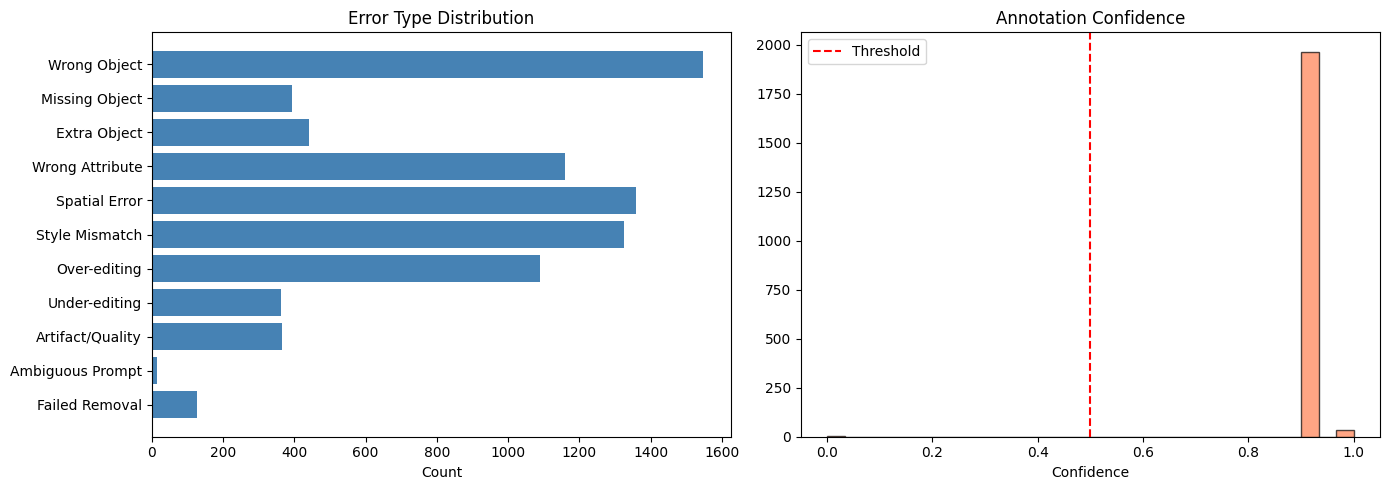

In [7]:
# Cell 7: Annotation statistics
import matplotlib.pyplot as plt

error_counts = np.zeros(NUM_ERROR_CLASSES)
for labels_str in df["error_labels"]:
    if isinstance(labels_str, str):
        labels = json.loads(labels_str)
        if len(labels) == NUM_ERROR_CLASSES:
            error_counts += np.array(labels)

conf = df["annotation_confidence"].astype(float)
has_err = df["has_error"].astype(bool)

print("Error Distribution:")
for i, count in enumerate(error_counts):
    print(f"  {ERROR_TAXONOMY[i]:20s}: {int(count):4d} ({count/len(df)*100:.1f}%)")
print(f"\nSamples with errors: {has_err.sum()}/{len(df)} ({has_err.sum()/len(df)*100:.1f}%)")
print(f"Confidence: mean={conf.mean():.3f}, median={conf.median():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([ERROR_TAXONOMY[i] for i in range(NUM_ERROR_CLASSES)], error_counts, color="steelblue")
axes[0].set_xlabel("Count")
axes[0].set_title("Error Type Distribution")
axes[0].invert_yaxis()
axes[1].hist(conf.dropna(), bins=30, color="coral", edgecolor="black", alpha=0.7)
axes[1].axvline(0.5, color="red", linestyle="--", label="Threshold")
axes[1].set_xlabel("Confidence")
axes[1].set_title("Annotation Confidence")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "annotation_stats.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 4: Training
BLIP-2 ViT (frozen) + XLM-RoBERTa (last 2 layers unfrozen) → cross-attention fusion → 11-class MLP.

In [8]:
# Cell 8: Dataset & Model setup for training
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import Blip2Model, Blip2Processor, XLMRobertaTokenizer, XLMRobertaModel
import torch.nn as nn
import torch.nn.functional as F

# ── Dataset class ──
class EditErrorDataset(Dataset):
    def __init__(self, dataframe, image_base_dir, blip_processor, xlmr_tokenizer, max_text_len=128):
        self.df = dataframe.reset_index(drop=True)
        self.image_base = image_base_dir
        self.blip_proc = blip_processor
        self.xlmr_tok = xlmr_tokenizer
        self.max_text_len = max_text_len
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load images
        src_img = Image.open(os.path.join(self.image_base, row["source_image_path"])).convert("RGB")
        tgt_img = Image.open(os.path.join(self.image_base, row["target_image_path"])).convert("RGB")
        
        src_pixels = self.blip_proc(images=src_img, return_tensors="pt")["pixel_values"].squeeze(0)
        tgt_pixels = self.blip_proc(images=tgt_img, return_tensors="pt")["pixel_values"].squeeze(0)
        
        # Text — pick a random language version
        lang_cols = ["instruction", "instruction_hi", "instruction_bn", "instruction_ne"]
        available = [c for c in lang_cols if c in row.index and pd.notna(row[c])]
        text_col = np.random.choice(available)
        text = row[text_col]
        
        text_enc = self.xlmr_tok(text, max_length=self.max_text_len, padding="max_length",
                                  truncation=True, return_tensors="pt")
        
        # Labels
        labels = json.loads(row["error_labels"]) if isinstance(row["error_labels"], str) else row["error_labels"]
        labels = torch.tensor(labels, dtype=torch.float32)
        
        return {
            "src_pixels": src_pixels,
            "tgt_pixels": tgt_pixels,
            "input_ids": text_enc["input_ids"].squeeze(0),
            "attention_mask": text_enc["attention_mask"].squeeze(0),
            "labels": labels,
        }


# ── Cross-attention fusion ──
class CrossAttentionFusion(nn.Module):
    def __init__(self, vision_dim=1408, text_dim=768, hidden_dim=512, num_heads=8):
        super().__init__()
        self.v_proj = nn.Linear(vision_dim, hidden_dim)
        self.t_proj = nn.Linear(text_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True, dropout=0.1)
        self.norm = nn.LayerNorm(hidden_dim)
    
    def forward(self, vision_feats, text_feats):
        v = self.v_proj(vision_feats)
        t = self.t_proj(text_feats)
        attn_out, _ = self.cross_attn(query=t, key=v, value=v)
        return self.norm(attn_out + t)


# ── Full classifier ──
class EditErrorClassifier(nn.Module):
    def __init__(self, num_classes=11, vision_dim=1408, text_dim=768, hidden_dim=512):
        super().__init__()
        self.cross_attn = CrossAttentionFusion(vision_dim, text_dim, hidden_dim)
        
        # MLP: [src_pool, tgt_pool, delta_pool, text_pool] -> classes
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 + vision_dim * 2, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )
    
    def forward(self, src_vision, tgt_vision, text_feats):
        # Pool vision: mean over sequence dim
        src_pool = src_vision.mean(dim=1)  # (B, vision_dim)
        tgt_pool = tgt_vision.mean(dim=1)
        delta = tgt_vision - src_vision
        
        # Cross-attention between delta and text
        fused = self.cross_attn(delta, text_feats)  # (B, seq, hidden)
        fused_pool = fused.mean(dim=1)  # (B, hidden)
        text_pool = text_feats.mean(dim=1)  # (B, hidden) -- projected inside cross_attn
        text_pool_proj = self.cross_attn.t_proj(text_pool)  # (B, hidden)
        
        combined = torch.cat([src_pool, tgt_pool, fused_pool, text_pool_proj], dim=1)
        return self.classifier(combined)


print("Dataset and model classes defined.")

Dataset and model classes defined.


In [9]:
# Cell 9: Training loop
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load backbones
print("Loading BLIP-2 processor & vision encoder...")
blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model = Blip2Model.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16)
blip_vision = blip_model.vision_model.to(device)
blip_vision.eval()
for p in blip_vision.parameters():
    p.requires_grad = False
del blip_model
gc.collect()
torch.cuda.empty_cache()

print("Loading XLM-RoBERTa...")
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
xlmr_model = XLMRobertaModel.from_pretrained("xlm-roberta-base").to(device)
# Freeze all but last 2 layers
for name, p in xlmr_model.named_parameters():
    p.requires_grad = False
for p in xlmr_model.encoder.layer[-2:].parameters():
    p.requires_grad = True
for p in xlmr_model.pooler.parameters():
    p.requires_grad = True

print(f"GPU memory after backbone load: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Split data
train_df, val_df = train_test_split(df, test_size=VAL_SPLIT, random_state=SEED)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

train_ds = EditErrorDataset(train_df, OUTPUT_DIR, blip_processor, xlmr_tokenizer)
val_ds = EditErrorDataset(val_df, OUTPUT_DIR, blip_processor, xlmr_tokenizer)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Classifier
classifier = EditErrorClassifier(num_classes=NUM_ERROR_CLASSES).to(device)

# Compute pos_weight from training labels
all_labels = np.array([json.loads(l) if isinstance(l, str) else l for l in train_df["error_labels"]])
pos_counts = all_labels.sum(axis=0)
neg_counts = len(all_labels) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer: different LR for backbone vs classifier
optimizer = torch.optim.AdamW([
    {"params": [p for p in xlmr_model.parameters() if p.requires_grad], "lr": LR * 0.1},
    {"params": classifier.parameters(), "lr": LR},
], weight_decay=0.01)

total_steps = len(train_loader) * TRAIN_EPOCHS // GRAD_ACCUM
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[LR*0.1, LR],
                                                  total_steps=total_steps, pct_start=0.1)
scaler = GradScaler()

print(f"\nTraining config: epochs={TRAIN_EPOCHS}, batch={BATCH_SIZE}, grad_accum={GRAD_ACCUM}")
print(f"Total steps: {total_steps}")
print(f"Trainable params: classifier={sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}, "
      f"xlmr={sum(p.numel() for p in xlmr_model.parameters() if p.requires_grad):,}")

Loading BLIP-2 processor & vision encoder...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPU memory after backbone load: 3.11 GB
Train: 1700, Val: 300
pos_weight: tensor([  0.2928,   4.0898,   3.5093,   0.7172,   0.4821,   0.5111,   0.8221,
          4.5016,   4.4839, 153.5454,  14.1786], device='cuda:0')

Training config: epochs=5, batch=4, grad_accum=8
Total steps: 265
Trainable params: classifier=6,630,411, xlmr=14,766,336


In [10]:
# Cell 10: Execute training
best_val_f1 = 0.0
train_losses = []
val_f1s = []

for epoch in range(TRAIN_EPOCHS):
    # ── Train ──
    classifier.train()
    xlmr_model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{TRAIN_EPOCHS} [Train]")
    for step, batch in enumerate(pbar):
        src_px = batch["src_pixels"].to(device, dtype=torch.float16)
        tgt_px = batch["tgt_pixels"].to(device, dtype=torch.float16)
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        with autocast(device_type="cuda", dtype=torch.float16):
            # Vision features (frozen)
            with torch.no_grad():
                src_feats = blip_vision(src_px).last_hidden_state.float()
                tgt_feats = blip_vision(tgt_px).last_hidden_state.float()
            
            # Text features
            text_out = xlmr_model(input_ids=input_ids, attention_mask=attn_mask)
            text_feats = text_out.last_hidden_state
            
            logits = classifier(src_feats, tgt_feats, text_feats)
            loss = criterion(logits, labels) / GRAD_ACCUM
        
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM
        
        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(classifier.parameters()) + [p for p in xlmr_model.parameters() if p.requires_grad],
                max_norm=1.0
            )
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        
        pbar.set_postfix({"loss": f"{loss.item()*GRAD_ACCUM:.4f}"})
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ── Validate ──
    classifier.eval()
    xlmr_model.eval()
    all_preds, all_labels_list = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{TRAIN_EPOCHS} [Val]"):
            src_px = batch["src_pixels"].to(device, dtype=torch.float16)
            tgt_px = batch["tgt_pixels"].to(device, dtype=torch.float16)
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            with autocast(device_type="cuda", dtype=torch.float16):
                src_feats = blip_vision(src_px).last_hidden_state.float()
                tgt_feats = blip_vision(tgt_px).last_hidden_state.float()
                text_out = xlmr_model(input_ids=input_ids, attention_mask=attn_mask)
                text_feats = text_out.last_hidden_state
                logits = classifier(src_feats, tgt_feats, text_feats)
            
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.append(preds)
            all_labels_list.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels_arr = np.concatenate(all_labels_list)
    
    val_f1 = f1_score(all_labels_arr, all_preds, average="macro", zero_division=0)
    val_f1_micro = f1_score(all_labels_arr, all_preds, average="micro", zero_division=0)
    val_f1s.append(val_f1)
    
    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_f1_macro={val_f1:.4f}, val_f1_micro={val_f1_micro:.4f}")
    
    # Save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        os.makedirs(MODEL_SAVE, exist_ok=True)
        torch.save({
            "classifier": classifier.state_dict(),
            "xlmr_unfrozen": {k: v for k, v in xlmr_model.state_dict().items()},
            "epoch": epoch + 1,
            "val_f1": val_f1,
        }, os.path.join(MODEL_SAVE, "best_model.pt"))
        print(f"  -> Saved best model (f1={val_f1:.4f})")

print(f"\nTraining complete! Best val F1: {best_val_f1:.4f}")

Epoch 1/5 [Train]:   0%|          | 0/425 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1: train_loss=0.8668, val_f1_macro=0.2446, val_f1_micro=0.4646
  -> Saved best model (f1=0.2446)


Epoch 2/5 [Train]:   0%|          | 0/425 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/75 [00:00<?, ?it/s]

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78930cfd0900><function _MultiProcessingDataLoaderIter.__del__ at 0x78930cfd0900>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
        if w.is_alive():if w.is_alive():

             ^ ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Epoch 4: train_loss=0.8647, val_f1_macro=0.3229, val_f1_micro=0.4410
  -> Saved best model (f1=0.3229)


Epoch 5/5 [Train]:   0%|          | 0/425 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 5: train_loss=0.8682, val_f1_macro=0.3225, val_f1_micro=0.4384

Training complete! Best val F1: 0.3229


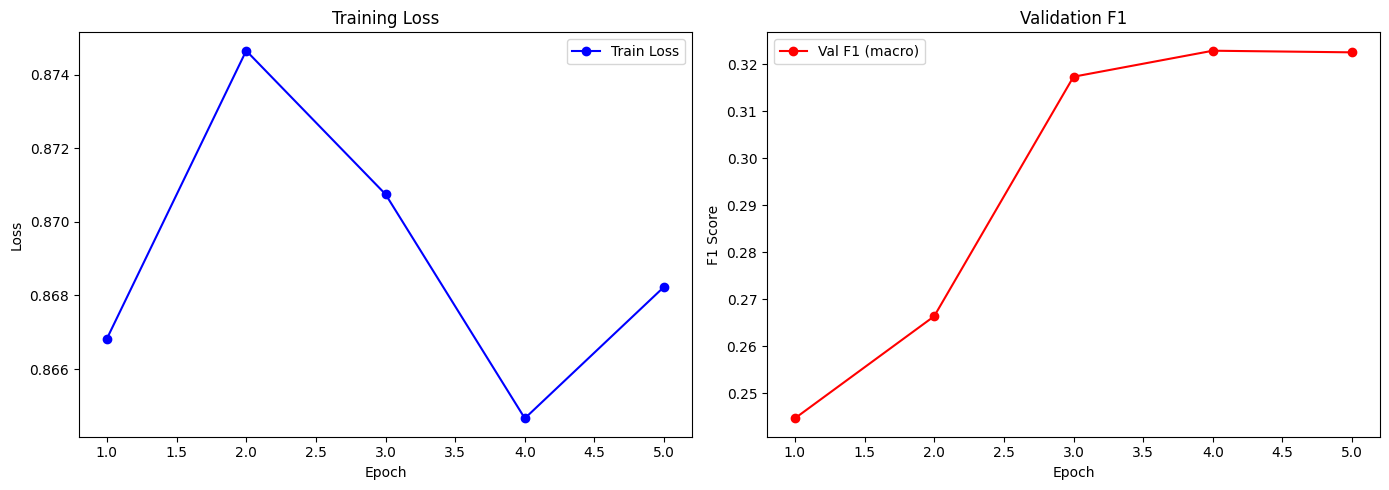


Per-class metrics (last epoch):
                  precision    recall  f1-score   support

    Wrong Object       0.89      0.03      0.07       233
  Missing Object       0.53      0.32      0.40        59
    Extra Object       0.45      0.40      0.42        63
 Wrong Attribute       0.58      0.94      0.72       170
   Spatial Error       0.71      0.05      0.09       212
  Style Mismatch       0.69      0.20      0.31       199
    Over-editing       0.55      0.87      0.67       156
   Under-editing       0.49      0.46      0.48        54
Artifact/Quality       0.33      0.48      0.39        54
Ambiguous Prompt       0.00      0.00      0.00         3
  Failed Removal       0.00      0.00      0.00        15

       micro avg       0.54      0.37      0.44      1218
       macro avg       0.48      0.34      0.32      1218
    weighted avg       0.64      0.37      0.35      1218
     samples avg       0.52      0.35      0.36      1218



In [ ]:
# Cell 11: Training visualization & per-class metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(train_losses)+1), train_losses, "b-o", label="Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot(range(1, len(val_f1s)+1), val_f1s, "r-o", label="Val F1 (macro)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Validation F1")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-class F1
from sklearn.metrics import classification_report
print("\nPer-class metrics (last epoch):")
target_names = [ERROR_TAXONOMY[i] for i in range(NUM_ERROR_CLASSES)]
print(classification_report(all_labels_arr, all_preds, target_names=target_names, zero_division=0))

In [ ]:
# Cell 12: Final summary
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"Dataset: {HF_DATASET}")
print(f"Samples: {len(df)}")
print(f"Languages: EN, HI, BN, NE")
print(f"\nCheckpoints:")
for ckpt_name, ckpt_path in [("Data", CKPT_DATA), ("Translation", CKPT_TRANS), ("Annotation", CKPT_ANNOT)]:
    exists = os.path.exists(ckpt_path)
    size = f"{os.path.getsize(ckpt_path)/1e6:.1f}MB" if exists else "N/A"
    print(f"  {ckpt_name:12s}: {'OK' if exists else 'MISSING':8s} {size:>10s}  {ckpt_path}")

model_exists = os.path.exists(os.path.join(MODEL_SAVE, "best_model.pt"))
if model_exists:
    msize = os.path.getsize(os.path.join(MODEL_SAVE, "best_model.pt")) / 1e6
    print(f"  {'Model':12s}: {'OK':8s} {msize:>9.1f}MB  {MODEL_SAVE}/best_model.pt")
    print(f"\nBest validation F1 (macro): {best_val_f1:.4f}")

for lang in ["hi", "bn", "ne"]:
    if f"low_confidence_{lang}" in df.columns:
        low = df[f"low_confidence_{lang}"].sum()
        avg = df[f"translation_confidence_{lang}"].mean()
        print(f"Translation {lang.upper()}: avg_conf={avg:.3f}, low={low}/{len(df)}")

print(f"\nOutput directory:")
!du -sh {OUTPUT_DIR}/*

In [ ]:
!zip -r /kaggle/working/my_output.zip /kaggle/working/